# Sessions

This dataset shows the annual sessions on workstations at Toronto Public Library branches.

# 0. imports

In [1]:
import os
from dotenv import load_dotenv

load_dotenv()
cwd = os.environ["REPO_ROOT"]
os.chdir(cwd)

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

from utils.download_data import download_data
import math
pd.set_option('display.max_colwidth', 50)
pd.set_option('display.max_columns', None)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 598 entries, 0 to 597
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Year        598 non-null    object
 1   BranchCode  598 non-null    object
 2   Sessions    598 non-null    int64 
dtypes: int64(1), object(2)
memory usage: 14.1+ KB
None
   Year BranchCode  Sessions
0  2012         AB    132024
1  2012        ACD    131353
2  2012         AD     16279
3  2012         AG    140407
4  2012         AH     11895


<Axes: xlabel='Year'>

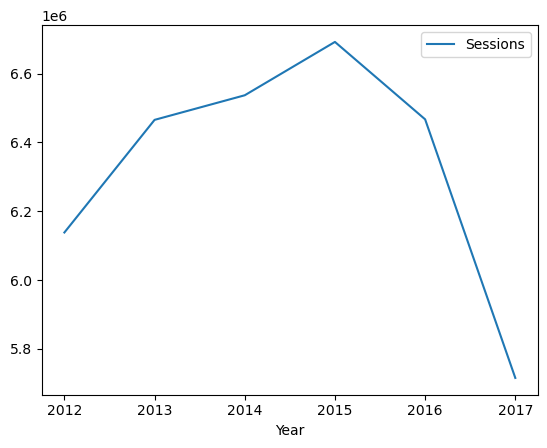

In [2]:
# Datasets are called "packages". Each package can contain many "resources"
# To retrieve the metadata for this package and its resources, use the package name in this page's URL:
params = { "id": "library-workstation-usage"}
sessions_file = cwd+"/data/library-workstation-usage.csv"

download_data(params, sessions_file)
usecols = ['Year', 'BranchCode', 'Sessions']
sessions = pd.read_csv(sessions_file, usecols=usecols, parse_dates=["Year"], date_format="%Y")
sessions['Year'] = sessions["Year"].dt.year.astype("object")
print(sessions.info())
print(sessions.head())

# Plot annual sessions at TPL
sessions[['Year', 'Sessions']].groupby('Year').sum().plot.line()

In [3]:
# Datasets are called "packages". Each package can contain many "resources"
# To retrieve the metadata for this package and its resources, use the package name in this page's URL:
params = { "id": "library-branch-general-information"}
branch_info_file = cwd+"/data/library-branch-general-information.csv"

download_data(params, branch_info_file)
# usecols = ["BranchCode", "BranchName", "PhysicalBranch"]
# branch_info = pd.read_csv(branch_info_file, usecols=usecols)
branch_info = pd.read_csv(branch_info_file)
print(branch_info.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112 entries, 0 to 111
Data columns (total 27 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   _id                   112 non-null    int64  
 1   BranchCode            112 non-null    object 
 2   PhysicalBranch        112 non-null    int64  
 3   BranchName            112 non-null    object 
 4   Address               103 non-null    object 
 5   PostalCode            103 non-null    object 
 6   Website               108 non-null    object 
 7   Telephone             105 non-null    object 
 8   SquareFootage         110 non-null    object 
 9   PublicParking         100 non-null    object 
 10  KidsStop              100 non-null    float64
 11  LeadingReading        100 non-null    float64
 12  CLC                   100 non-null    float64
 13  DIH                   100 non-null    float64
 14  TeenCouncil           100 non-null    float64
 15  YouthHub              1

## 0.1. data

In [4]:
# sessions_branch_info = pd.concat(objs=, axis=1, join="outer")
sessions_branch_info = sessions.merge(right=branch_info, indicator=True, left_on="BranchCode", right_on="BranchCode", how="left",validate="m:1")
print(sessions_branch_info.head())

   Year BranchCode  Sessions  _id  PhysicalBranch       BranchName  \
0  2012         AB    132024    1               1           Albion   
1  2012        ACD    131353    2               1  Albert Campbell   
2  2012         AD     16279    3               1        Alderwood   
3  2012         AG    140407    4               1        Agincourt   
4  2012         AH     11895    5               1   Armour Heights   

                                     Address PostalCode  \
0     1515 Albion Road, Toronto, ON, M9V 1B2    M9V 1B2   
1  496 Birchmount Road, Toronto, ON, M1K 1N8    M1K 1N8   
2      2 Orianna Drive, Toronto, ON, M8W 4Y1    M8W 4Y1   
3     155 Bonis Avenue, Toronto, ON, M1T 3W6    M1T 3W6   
4     2140 Avenue Road, Toronto, ON, M5M 4M7    M5M 4M7   

                             Website     Telephone SquareFootage  \
0          https://www.tpl.ca/albion  416-394-5170         29000   
1  https://www.tpl.ca/albertcampbell  416-396-8890         28957   
2       https://www.

In [5]:
data = pd.read_csv("data/data_binary_classification.csv")

data["Sessions"] = sessions_branch_info["Sessions"]

data.to_csv(path_or_buf="data/data_binary_classification.csv", index=False)

# 1. PhysicalBranch (Online vs. Physical)

In [6]:
sessions_by_physical_branch = sessions_branch_info[["Year", "PhysicalBranch", "Sessions"]].pivot_table(index="Year", columns="PhysicalBranch", values="Sessions", aggfunc="sum")
sessions_by_physical_branch

PhysicalBranch,0,1
Year,,
2012,631,6137561
2013,538,6465210
2014,400,6536886
2015,475,6691957
2016,550,6466769
2017,463,5714788


In [7]:
sessions_by_physical_branch_melted = sessions_by_physical_branch.reset_index().melt(id_vars="Year", var_name="PhysicalBranch", value_name="Sessions")

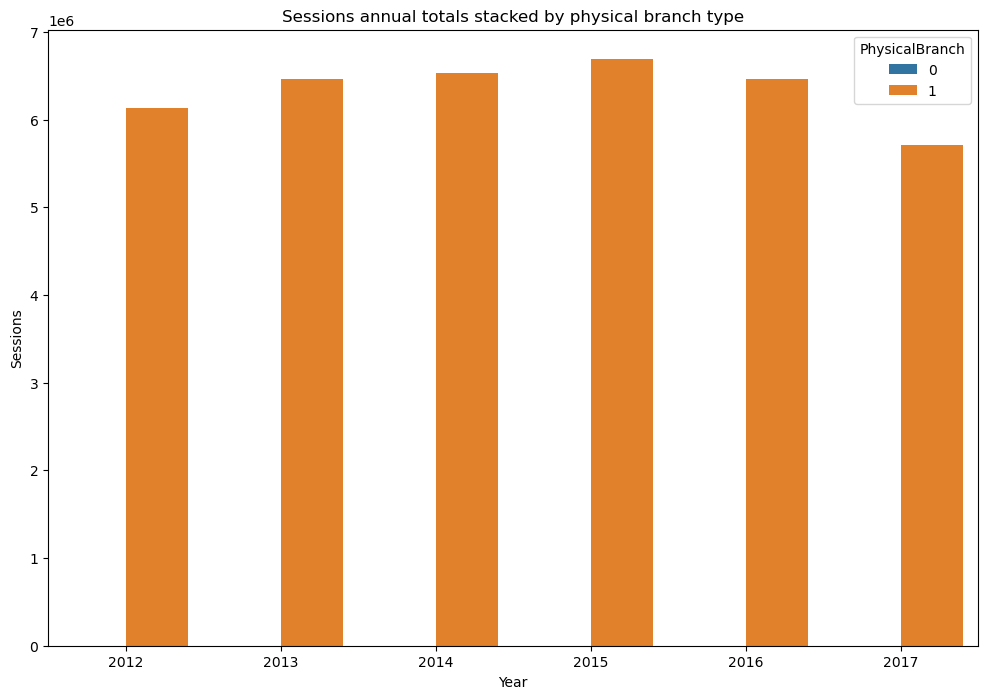

In [8]:
fig = plt.figure(1, figsize=(12, 8))
ax = fig.add_subplot(111)

plot = sns.barplot(
    data=sessions_by_physical_branch_melted,
    x="Year",
    y="Sessions",
    hue="PhysicalBranch",
    dodge=True,
    ax=ax,
    palette="tab10",
    errorbar=None
)

ax.set(
    title="Sessions annual totals stacked by physical branch type",
    xlabel="Year",
    ylabel="Sessions",
)
# ax.xaxis.set_ticklabels([])
# ax.yaxis.set_ticklabels([])

# for container in ax.containers:
#     ax.bar_label(container=container, labels=)


plt.show()
fig.savefig(fname="output/annual_sessions_by_physical_branch_indicator.png")

In [9]:
sessions_by_physical_branch_pct = sessions_by_physical_branch.copy(deep=True)
sessions_by_physical_branch_pct[0] = sessions_by_physical_branch_pct[0] / (sessions_by_physical_branch_pct[0] + sessions_by_physical_branch_pct[1]) * 100
sessions_by_physical_branch_pct[1] = sessions_by_physical_branch_pct[1] / (sessions_by_physical_branch[0] + sessions_by_physical_branch_pct[1]) * 100
print(sessions_by_physical_branch_pct)

PhysicalBranch         0          1
Year                               
2012            0.010280  99.989720
2013            0.008321  99.991679
2014            0.006119  99.993881
2015            0.007098  99.992902
2016            0.008504  99.991496
2017            0.008101  99.991899


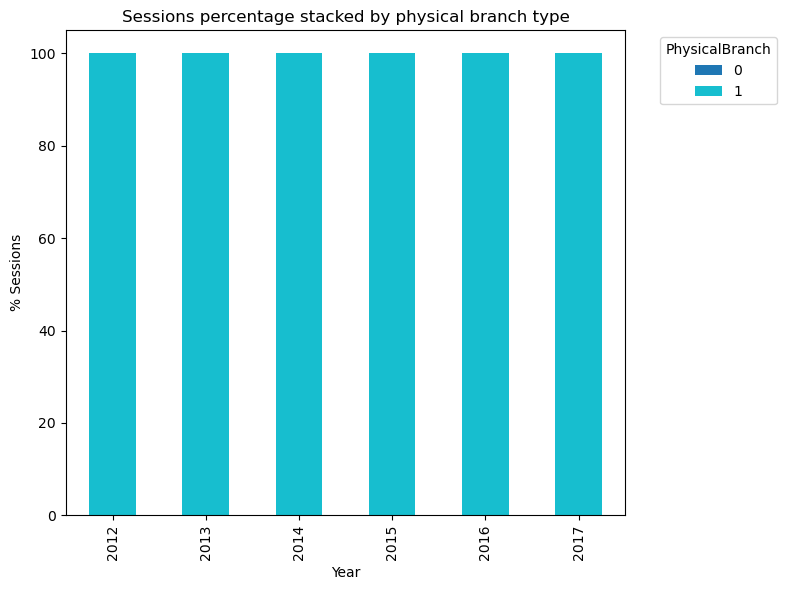

In [10]:
# Create stacked bar chart
fig, ax = plt.subplots(figsize=(8, 6))
sessions_by_physical_branch_pct.plot(kind='bar', stacked=True, ax=ax, colormap='tab10')

ax.set(
    title="Sessions percentage stacked by physical branch type",
    xlabel="Year",
    ylabel="% Sessions",
)
ax.legend(title='PhysicalBranch', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()
fig.savefig(fname="output/annual_percentage_sessions_by_physical_branch_indicator.png")

## Log Scale Plot

In [11]:
sessions_by_physical_branch = sessions_branch_info[["Year", "PhysicalBranch", "Sessions"]].pivot_table(index="Year", columns="PhysicalBranch", values="Sessions", aggfunc="sum")
print(sessions_by_physical_branch)
sessions_by_physical_branch[0] = np.log10(sessions_by_physical_branch[0])
sessions_by_physical_branch[1] = np.log10(sessions_by_physical_branch[1])
print(sessions_by_physical_branch)
sessions_by_physical_branch_melted = sessions_by_physical_branch.reset_index().melt(id_vars="Year", var_name="PhysicalBranch", value_name="Sessions")

PhysicalBranch    0        1
Year                        
2012            631  6137561
2013            538  6465210
2014            400  6536886
2015            475  6691957
2016            550  6466769
2017            463  5714788
PhysicalBranch         0         1
Year                              
2012            2.800029  6.787996
2013            2.730782  6.810583
2014            2.602060  6.815371
2015            2.676694  6.825553
2016            2.740363  6.810687
2017            2.665581  6.757000


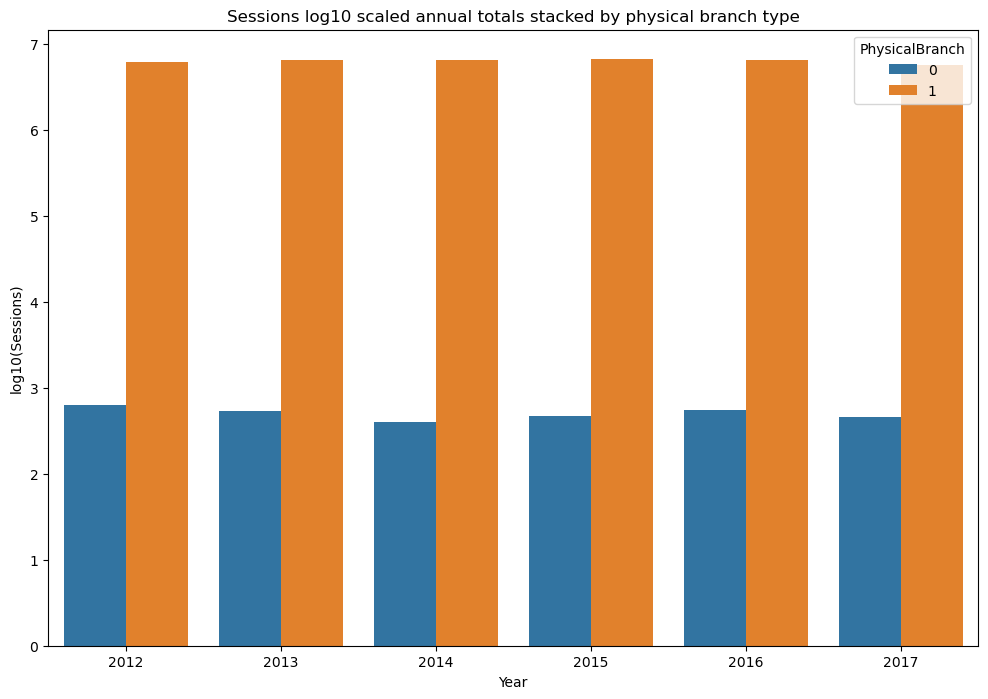

In [12]:
fig = plt.figure(1, figsize=(12, 8))
ax = fig.add_subplot(111)

plot = sns.barplot(
    data=sessions_by_physical_branch_melted,
    x="Year",
    y="Sessions",
    hue="PhysicalBranch",
    dodge=True,
    ax=ax,
    palette="tab10",
    errorbar=None
)

ax.set(
    title="Sessions log10 scaled annual totals stacked by physical branch type",
    xlabel="Year",
    ylabel="log10(Sessions)",
)
# ax.xaxis.set_ticklabels([])
# ax.yaxis.set_ticklabels([])

# for container in ax.containers:
#     ax.bar_label(container=container, labels=)


plt.show()
fig.savefig(fname="output/log_annual_sessions_by_physical_branch_indicator.png")


## 1.0 Online Branch drilldown

In [13]:
online_sessions = sessions_branch_info[sessions_branch_info['PhysicalBranch'] == 0]
print(online_sessions.head())

     Year BranchCode  Sessions  _id  PhysicalBranch           BranchName  \
79   2012         SB       631   92               0  Sunnybrook Hospital   
177  2013         SB       538   92               0  Sunnybrook Hospital   
277  2014         SB       400   92               0  Sunnybrook Hospital   
377  2015         SB       475   92               0  Sunnybrook Hospital   
478  2016         SB       550   92               0  Sunnybrook Hospital   

                                               Address PostalCode  \
79   2075 Bayview Avenue, Aging and Veterans Care, ...    M4N 3M5   
177  2075 Bayview Avenue, Aging and Veterans Care, ...    M4N 3M5   
277  2075 Bayview Avenue, Aging and Veterans Care, ...    M4N 3M5   
377  2075 Bayview Avenue, Aging and Veterans Care, ...    M4N 3M5   
478  2075 Bayview Avenue, Aging and Veterans Care, ...    M4N 3M5   

                                 Website                Telephone  \
79   https://www.tpl.ca/hospital-service  416-480-6100  EXT

In [14]:
branch_stats = online_sessions.groupby(by='BranchCode').Sessions.describe()
branch_stats.sort_values(by='max', ascending=False)

,count,mean,std,min,25%,50%,75%,max
BranchCode,,,,,,,,
SB,6.0,509.5,80.693866,400.0,466.0,506.5,547.0,631.0


## 1.1 Library Collections branches

Osborne and Merill Collections at Lilian H.Smith branch

In [15]:
branch_info[branch_info['BranchCode'] == 'OS']

,_id,BranchCode,PhysicalBranch,BranchName,Address,PostalCode,Website,Telephone,SquareFootage,PublicParking,KidsStop,LeadingReading,CLC,DIH,TeenCouncil,YouthHub,AdultLiteracyProgram,Workstations,ServiceTier,Lat,Long,NBHDNo,NBHDName,TPLNIA,WardNo,WardName,PresentSiteYear
75,76,OS,0,Osborne Collection,"239 College Street, 4th floor, Toronto, ON, M5...",M5T 1R5,https://www.tpl.ca/osborne,416-393-7753,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,RR,43.65785,-79.39864,NaN,NaN,NaN,NaN,NaN,NaN


In [16]:
branch_info[branch_info['BranchCode'] == 'ME']

,_id,BranchCode,PhysicalBranch,BranchName,Address,PostalCode,Website,Telephone,SquareFootage,PublicParking,KidsStop,LeadingReading,CLC,DIH,TeenCouncil,YouthHub,AdultLiteracyProgram,Workstations,ServiceTier,Lat,Long,NBHDNo,NBHDName,TPLNIA,WardNo,WardName,PresentSiteYear
67,68,ME,0,Merril Collection,"239 College Street, 3rd floor, Toronto, ON, M5...",M5T 1R5,https://www.tpl.ca/merril,416-393-7748,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,RR,43.657222,-79.398333,NaN,NaN,NaN,NaN,NaN,NaN


## 1.3 Sunnybrook

The service provided supports the Sunnybrook community - its hospital patients, veterans and staff.

In [17]:
branch_info[branch_info['BranchCode'] == 'SB']

,_id,BranchCode,PhysicalBranch,BranchName,Address,PostalCode,Website,Telephone,SquareFootage,PublicParking,KidsStop,LeadingReading,CLC,DIH,TeenCouncil,YouthHub,AdultLiteracyProgram,Workstations,ServiceTier,Lat,Long,NBHDNo,NBHDName,TPLNIA,WardNo,WardName,PresentSiteYear
91,92,SB,0,Sunnybrook Hospital,"2075 Bayview Avenue, Aging and Veterans Care, ...",M4N 3M5,https://www.tpl.ca/hospital-service,416-480-6100 EXT 62624,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<Axes: xlabel='Year', ylabel='Sessions'>

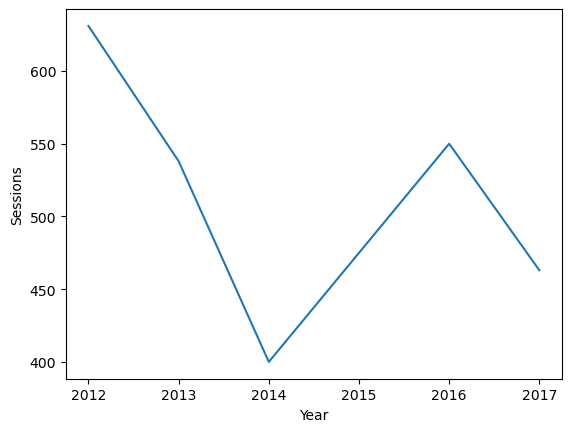

In [18]:
Sunnybrook = online_sessions[online_sessions['BranchCode'] == 'SB']

sns.lineplot(data=Sunnybrook, x='Year', y='Sessions')

# APPENDIX

## A.1 Correlation plot

Correlation of `Sessions` in `BranchCode` feature

In [19]:
sessions_by_branch = sessions.pivot(columns='BranchCode',index='Year',values='Sessions')
sessions_by_branch.isna().sum().sort_values(ascending=False)[:10]

BranchCode
SC    3
FO    2
CL    1
FV    1
MD    1
AH    0
AG    0
BB    0
AN    0
BD    0
dtype: int64

In [20]:
from sklearn.impute import SimpleImputer

sessions_by_branch_imputed = sessions_by_branch.copy(deep=True)
imputation_strategies = {"median": ["CL", "FV", "MD"],
                        "constant": ["FO", "SC"]}

for strategy, columns in imputation_strategies.items():
    cols_to_impute = [col for col in columns if col in sessions_by_branch_imputed.columns]

    if strategy == "constant":
        imputer = SimpleImputer(missing_values=pd.NA, strategy=strategy, fill_value=0)
    else:
        imputer = SimpleImputer(missing_values=pd.NA, strategy=strategy)
    
    sessions_by_branch_imputed[cols_to_impute] = imputer.fit_transform(sessions_by_branch_imputed[cols_to_impute])

sessions_by_branch_imputed

BranchCode,AB,ACD,AD,AG,AH,AN,AP,BB,BC,BD,BE,BF,BL,BR,BRW,BUR,CC,CE,CED,CH,CL,CS,DA,DM,DO,DP,DR,DT,DU,EA,EB,EG,EN,ES,FH,FO,FP,FV,GE,GHP,GW,HB,HC,HIL,HP,HS,HW,JD,JO,JS,KE,LB,LE,LO,LS,MA,MAL,MAS,MCG,MD,MI,MP,MRV,MS,ND,NE,NT,OV,PA,PE,PK,PL,PM,PU,PV,QS,RD,RI,RN,RX,SA,SB,SC,SI,SJ,SL,SP,ST,SW,SWS,TA,TH,TOD,TRL,VV,WE,WP,WS,WY,YO,YW
Year,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2012,132024.0,131353.0,16279.0,140407.0,11895.0,36663.0,18961.0,19784.0,25755.0,19911.0,45165.0,101666.0,177112.0,8276.0,41350.0,25885.0,18786.0,28740.0,240834.0,30061.0,484789.0,22640.0,35962.0,75424.0,103227.0,40648.0,48770.0,6192.0,54256.0,48329.0,8451.0,30367.0,21394.0,34997.0,20652.0,0.0,55771.0,164649.0,21811.0,46660.0,11027.0,8441.0,23497.0,32986.0,39306.0,31763.0,31205.0,71573.0,30753.0,46352.0,38399.0,26643.0,25308.0,42570.0,188318.0,35881.0,165136.0,132310.0,39797.0,55175.0,17454.0,5328.0,31081.0,34166.0,127600.0,12532.0,26430.0,35837.0,70725.0,10329.0,111474.0,60005.0,21846.0,15438.0,25879.0,12243.0,73429.0,131921.0,69640.0,20822.0,67645.0,631.0,0.0,15156.0,64006.0,23702.0,11709.0,37604.0,2759.0,129468.0,13881.0,80657.0,2820.0,727822.0,14772.0,40117.0,19629.0,105207.0,44020.0,32464.0,172783.0
2013,139402.0,133591.0,16238.0,180672.0,11250.0,30396.0,17788.0,22950.0,21560.0,22293.0,46488.0,112745.0,171160.0,84403.0,43375.0,27563.0,17750.0,29350.0,260191.0,31225.0,545403.0,21563.0,39138.0,81804.0,120176.0,52063.0,49088.0,7000.0,63350.0,43594.0,7575.0,29788.0,25243.0,39200.0,19988.0,0.0,59211.0,215656.0,21888.0,48736.0,12550.0,8675.0,22513.0,55275.0,41600.0,30800.0,36038.0,75575.0,28675.0,48988.0,38200.0,26575.0,27025.0,40425.0,189215.0,39548.0,181120.0,111379.0,44723.0,44575.0,21055.0,5675.0,30713.0,39950.0,117777.0,13700.0,22372.0,34600.0,72263.0,9638.0,128159.0,69688.0,20863.0,16875.0,41325.0,11863.0,73788.0,118823.0,67213.0,18938.0,69388.0,538.0,0.0,14225.0,62200.0,26075.0,11245.0,37838.0,2575.0,147925.0,15425.0,88100.0,3300.0,818494.0,13675.0,37488.0,16738.0,114088.0,43200.0,32475.0,176806.0
2014,142159.0,149898.0,16500.0,166023.0,11800.0,28629.0,18550.0,26263.0,24600.0,20538.0,41963.0,120551.0,174629.0,83069.0,42088.0,28275.0,18738.0,26025.0,258188.0,29988.0,496202.0,21663.0,38850.0,85624.0,118894.0,54988.0,49650.0,7150.0,59313.0,47626.0,6538.0,33350.0,23452.0,37063.0,20288.0,24150.0,51997.0,167961.0,23425.0,50442.0,12138.0,8900.0,24713.0,31088.0,44950.0,31213.0,34175.0,71413.0,28863.0,48763.0,39188.0,22363.0,23925.0,40625.0,183539.0,38513.0,175932.0,128615.0,44396.0,64538.0,22058.0,5613.0,30650.0,41363.0,106577.0,12938.0,23049.0,36975.0,71899.0,10063.0,133343.0,68339.0,19988.0,18088.0,22738.0,11150.0,74888.0,120461.0,68213.0,18875.0,66100.0,400.0,0.0,14225.0,65038.0,25688.0,13242.0,27963.0,2488.0,137354.0,14925.0,89775.0,6225.0,776844.0,14638.0,40363.0,19200.0,104775.0,37747.0,32850.0,185228.0
2015,142187.0,145984.0,16700.0,158536.0,11013.0,34038.0,16300.0,19700.0,24413.0,21100.0,48525.0,131127.0,179859.0,84937.0,41463.0,28463.0,18638.0,27188.0,243984.0,29788.0,477283.0,21188.0,37125.0,86525.0,109770.0,60138.0,43475.0,6688.0,54700.0,46633.0,6850.0,34325.0,19505.0,37650.0,21600.0,49513.0,50388.0,232297.0,25863.0,49572.0,12600.0,8725.0,21838.0,31550.0,43475.0,27700.0,21575.0,64375.0,25888.0,48325.0,37925.0,25550.0,25913.0,42075.0,176522.0,35975.0,170307.0,135937.0,42142.0,55913.0,21475.0,6138.0,32938.0,42363.0,112235.0,11325.0,22853.0,37863.0,75404.0,8113.0,127130.0,68269.0,18800.0,16450.0,22488.0,11100.0,73775.0,113426.0,65663.0,20063.0,67425.0,475.0,27325.0,13925.0,57375.0,22051.0,14813.0,34800.0,2600.0,138960.0,18588.0,79150.0,5438.0,901258.0,12950.0,46263.0,21425.0,106963.0,37263.0,32313.0,193860.0
2016,140606.0,149712.0,16338.0,103406.0,10988.0,29238.0,16563.0,19713.0,21763.0,18088.0,45825.0,121863.0,168193.0,84596.0,40138.0,24950.0,19413.0,28213.0,249984.0,30938.0,433079.0,21813.0,37150.0,88066.0,113701.0,59513.0,46688.0,6113.0,51225.0,45770.0,7325.0,30325.0,23800.0,18675.0,20350.0,480

In [21]:
sessions_correlation = sessions_by_branch_imputed.corr()
sessions_correlation

BranchCode,AB,ACD,AD,AG,AH,AN,AP,BB,BC,BD,BE,BF,BL,BR,BRW,BUR,CC,CE,CED,CH,CL,CS,DA,DM,DO,DP,DR,DT,DU,EA,EB,EG,EN,ES,FH,FO,FP,FV,GE,GHP,GW,HB,HC,HIL,HP,HS,HW,JD,JO,JS,KE,LB,LE,LO,LS,MA,MAL,MAS,MCG,MD,MI,MP,MRV,MS,ND,NE,NT,OV,PA,PE,PK,PL,PM,PU,PV,QS,RD,RI,RN,RX,SA,SB,SC,SI,SJ,SL,SP,ST,SW,SWS,TA,TH,TOD,TRL,VV,WE,WP,WS,WY,YO,YW
BranchCode,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
AB,1.000000,0.676983,0.325687,0.189741,-0.529674,-0.650865,-0.017455,0.374433,-0.213394,0.167519,0.120768,0.684656,-0.114047,0.895677,-0.027787,0.366489,0.127242,-0.324025,0.296924,-0.114927,-0.068931,-0.475027,0.617095,0.714652,0.599647,0.918088,-0.290843,0.532947,0.209220,-0.214206,-0.919020,0.460061,-0.049151,0.015681,0.018909,0.560929,-0.145615,0.493807,0.639778,0.370753,0.781188,0.564448,-0.086951,-0.016174,0.709128,-0.024673,-0.142145,-0.259264,-0.343182,0.347746,-0.159904,-0.220683,-0.148954,-0.093998,-0.008215,0.283415,0.425508,0.094899,0.363706,0.243475,0.630605,0.688612,0.200565,0.978206,-0.916310,-0.088778,-0.901388,0.425362,0.329655,-0.480837,0.940284,0.907486,-0.680225,0.459880,-0.074501,-0.597828,0.111083,-0.261737,0.025566,-0.416675,-0.265494,-0.768201,0.180894,-0.079636,-0.338044,0.061145,0.592378,-0.495820,-0.223630,0.201022,0.579463,0.227542,0.801119,0.616605,-0.327513,0.384346,0.114677,0.094680,-0.675482,-0.016789,0.517296
ACD,0.676983,1.000000,-0.179341,-0.386031,-0.392240,-0.226999,-0.490012,-0.102499,-0.349448,-0.537270,-0.403279,0.837317,-0.227275,0.685029,-0.164083,-0.278372,-0.086240,0.122767,-0.311848,0.278025,-0.553064,-0.613740,0.033800,0.913059,-0.025476,0.778898,-0.442055,-0.083713,-0.481340,-0.112402,-0.811840,0.030481,0.275710,-0.537932,0.360954,0.874145,-0.749465,0.319023,0.723666,-0.247186,0.083620,0.071804,-0.436846,-0.664218,0.474023,-0.570114,-0.632668,-0.723097,-0.729952,-0.280104,-0.059319,-0.736425,-0.623251,0.490104,-0.572383,-0.395170,-0.311514,0.380722,-0.318889,0.560452,0.842435,0.600235,0.623967,0.722136,-0.607153,-0.631076,-0.531609,0.197274,-0.207361,-0.622331,0.564100,0.513386,-0.197827,-0.090552,-0.725642,-0.758388,-0.322268,-0.659892,-0.483627,-0.533547,-0.681948,-0.744080,0.665952,-0.536223,-0.494399,-0.204233,0.840849,-0.801484,0.269416,-0.492982,0.060233,-0.352607,0.781604,0.618718,-0.553067,0.246501,0.694522,-0.666404,-0.982256,-0.540739,-0.020833
AD,0.325687,-0.179341,1.000000,0.259932,0.077203,-0.546878,0.877320,0.621912,0.725975,0.453801,0.687601,-0.279482,0.419657,-0.086198,-0.560286,0.925892,0.865121,-0.973153,0.866056,-0.962454,-0.056829,0.591728,0.306649,-0.338999,0.606741,0.146238,0.115958,0.511937,0.472088,0.614931,-0.132092,0.939390,-0.904412,0.494005,-0.313756,-0.159939,0.689034,-0.104704,0.122597,0.932014,0.664763,0.887292,0.564641,0.158887,0.210817,0.852836,0.433165,0.258364,0.574096,0.936412,-0.369582,0.710528,-0.059284,-0.525302,0.871876,0.654548,0.620781,0.426848,0.613441,0.272251,-0.489719,0.218459,-0.380262,0.244930,-0.444174,0.406946,-0.095588,0.891729,0.967006,0.148708,0.254035,0.157886,-0.892169,0.885954,0.266025,0.313616,0.472755,0.771522,0.915453,0.658458,-0.000565,0.057765,-0.585081,0.883869,0.197932,-0.090692,0.048334,0.193202,-0.928608,0.484260,0.691010,0.612196,0.274237,-0.072105,0.521641,0.663689,-0.377894,0.581430,0.170726,0.668785,0.907465
AG,0.189741,-0.386031,0.259932,1.000000,0.280566,-0.138677,0.296597,0.583699,0.234846,0.942643,0.120046,-0.140962,0.419550,0.111554,0.647302,0.601088,-0.204557,-0.243116,0.366471,-0.250200,0.898298,-0.054655,0.657476,-0.293827,0.457986,-0.136281,0.305415,0.860351,0.848526,-0.071880,-0.194517,0.342866,-0.133793,0.919676,-0.172382,-0.523525,0.484658,-0.184021,-0.184491,0.559509,0.485371,0.181131,0.692487,0.664104,0.604148,0.517200,0.741953,0.681311,0.582594,0.368351,0.601593,0.201352,0.500279,-0.928528,0.437791,0.658563,0.723885,-0.690553,0.884173,-0.171045,-0.271970,-0.416763,-0.781810,0.023798,-0.352822,0.666766,-0.161376,-0.103997,0.150411,0.544708,0.376962,0.165460,-0.162277,0

<Figure size 800x600 with 0 Axes>

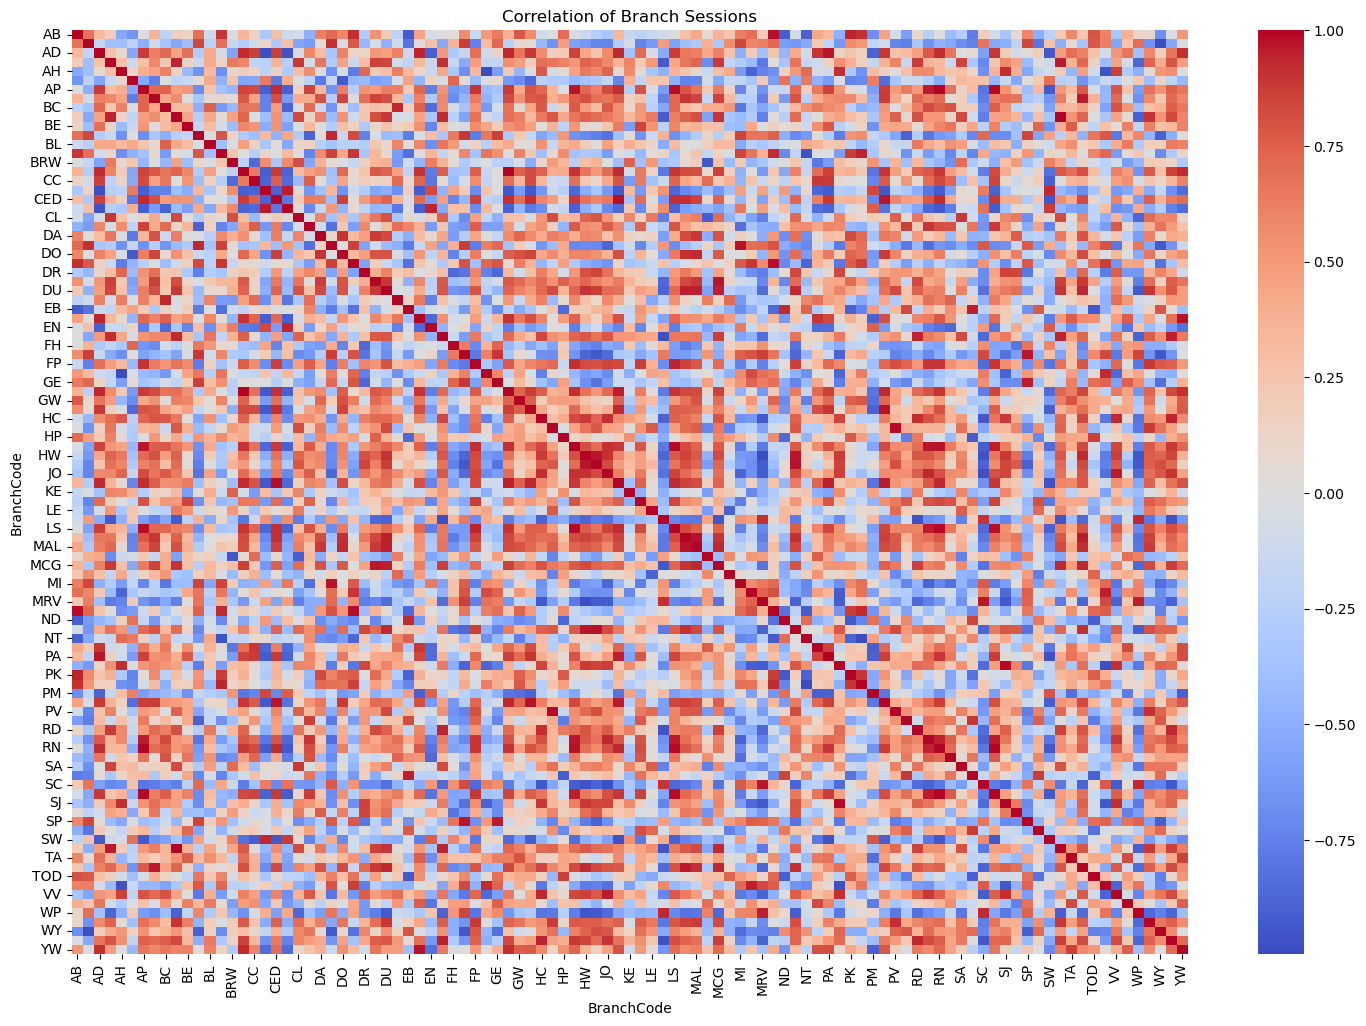

In [22]:
fig = plt.figure(1, figsize=(8, 6))
# ax = fig.add_subplot(111)

plt.figure(figsize=(18,12))
heatmap = sns.heatmap(data=sessions_correlation,cmap='coolwarm')

heatmap.set(
    title="Correlation of Branch Sessions",
    xlabel="BranchCode",
    ylabel="BranchCode",
)
# heatmap.xaxis.set_ticklabels([])
# heatmap.yaxis.set_ticklabels([])

# plt.show()
fig.savefig(fname="output/Branch_Sessions_Correlation.png")

## A.2 PCA

Single Valued Decomposition of `BranchCode` feature across `Year` dimensions

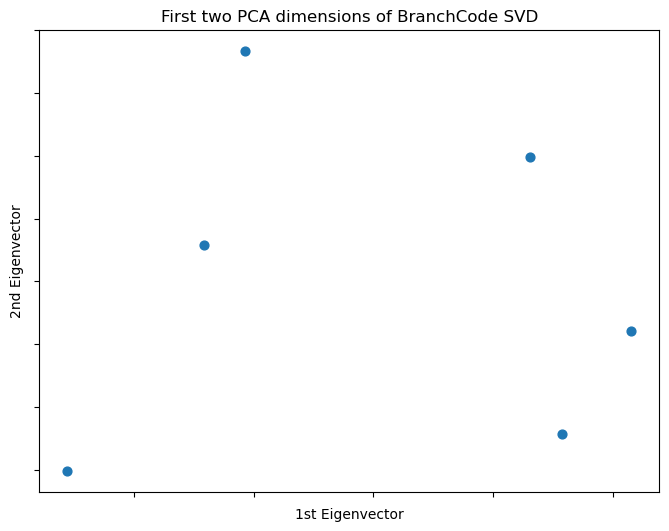

In [24]:
from sklearn.decomposition import PCA

fig = plt.figure(1, figsize=(8, 6))
ax = fig.add_subplot(111)
X_reduced = PCA(n_components=2).fit_transform(sessions_by_branch_imputed)
scatter = ax.scatter(
    X_reduced[:, 0],
    X_reduced[:, 1],
    s=40,
)

ax.set(
    title="First two PCA dimensions of BranchCode SVD",
    xlabel="1st Eigenvector",
    ylabel="2nd Eigenvector",
)
ax.xaxis.set_ticklabels([])
ax.yaxis.set_ticklabels([])

plt.show()
fig.savefig(fname="output/PCA_Sessions_2D.png")

In [25]:
X_reduced

array([[-127737.45165227,  -60252.84129996],
       [ -53500.97990131,   73462.87730306],
       [ -70803.9599689 ,   11632.90030564],
       [  65541.58581473,   39529.67501424],
       [ 107624.76408404,  -15859.27480721],
       [  78876.04162371,  -48513.33651577]])

In [26]:
X_reduced.shape

(6, 2)